**Filtering and Downsampling** <br>
This notebook serves the correction and rejection of artefacts in the EEG data. Independent Component Analysis (ICA) will be performed on the continuous data and the autoreject function on epoched data.

In [ ]:
# 1. Imports
import numpy as np
import mne
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path
import os
from autoreject import AutoReject, get_rejection_threshold

# 2. Configuration
deriv_root = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")

sub_number = "14"
task = "loc"
description = "filtResamp250"

# Subject folder
sub_dir = deriv_root / f"sub-{sub_number}" / "eeg"

# Input: filtered + downsampled recording
fname_input = (
    sub_dir
    / f"sub-{sub_number}_task-{task}_desc-{description}_eeg.fif"
)

# Output: cleaned recording
fname_cleaned = (
    sub_dir
    / f"sub-{sub_number}_task-{task}_desc-cleanEpochs_eeg.fif"
)

print(f"Working on Subject: {sub_number}")
print(f"Input file:   {fname_input}")
print(f"Output file:  {fname_cleaned}")

# 3. Loading the data

# Check if cleaned file already exists
if fname_cleaned.exists():
    print("Found existing cleaned file. Loading...")
    raw_eeg = mne.io.read_raw_fif(fname_cleaned, preload=True)

else:
    print("Loading filtered/downsampled file...")
    raw_eeg = mne.io.read_raw_fif(fname_input, preload=True)

# Extract events from annotations
events, event_id = mne.events_from_annotations(
    raw_eeg,
    verbose=False
)

Working on Subject: 14
Input file:   C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-filtResamp250_eeg.fif
Output file:  C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-cleanEpochs_eeg.fif


### Steps 5 & 6: Preliminary Epoching & ICA


In [ ]:
# ==========================================
# SCHRITT 5 & 6: Preliminary Epoching & ICA
# ==========================================
print("Create preliminary epochs for ICA fitting...")
# Für die ICA nutzen wir oft 1-Sekunden-Epochen ohne große Überlappung
tstep = 1.0
events_ica = mne.make_fixed_length_events(raw_eeg, duration=tstep)
epochs_ica = mne.Epochs(raw_eeg, events_ica, tmin=0.0, tmax=tstep, baseline=None, preload=True)

# Leichter Artefakt-Screen, um extreme Ausreißer vor der ICA zu verwerfen
# (ICA reagiert empfindlich auf extreme, seltene Artefakte)
reject_ica = get_rejection_threshold(epochs_ica)
epochs_ica.drop_bad(reject=reject_ica)

print("Führe ICA durch...")
# n_components leicht anpassen (meistens nutzt man nicht 100% der Kanäle)
ica = mne.preprocessing.ICA(n_components=0.99, random_state=42, method='picard')
ica.fit(epochs_ica)

Erstelle vorläufige Epochen für das ICA-Fitting...
Not setting metadata
2223 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2223 events and 251 original time points ...
0 bad epochs dropped
Estimating rejection dictionary for eeg
Estimating rejection dictionary for eog
    Rejecting  epoch based on EEG : ['AF7']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF7', 'AF8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF7', 'AF8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF8']
    Rejecting  epoch based on EEG : ['F3', 'TP9', 'CP5', 'P7', 'TP7', 'P5', 'PO7']
    Rejecting  epoch based on EEG : ['F3', 'P7']
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'AF8']
    Rejecting  epoch based on EEG : ['F3', 'P7']
    Rejecting  epoch based on EEG : ['Fp1', 'P7', 'Fp2']
    Rejecting  epoch based on EEG : ['F3', 'P7']
    Rejecting  epoch based

Method,picard
Fit parameters,max_iter=500
Fit,63 iterations on epochs (334834 samples)
ICA components,45
Available PCA components,63
Channel types,eeg
ICA components marked for exclusion,—


In [19]:
# ==========================================
# SCHRITT 7: Identifying and removing non-brain components
# ==========================================
print("Identifiziere EOG/ECG Artefakte...")
# Falls du EOG/ECG Kanäle hast, kann MNE diese automatisch finden:
eog_indices, eog_scores = ica.find_bads_eog(raw_eeg)
ica.exclude = eog_indices

Identifiziere EOG/ECG Artefakte...
Using EOG channels: HEOG, VEOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.5

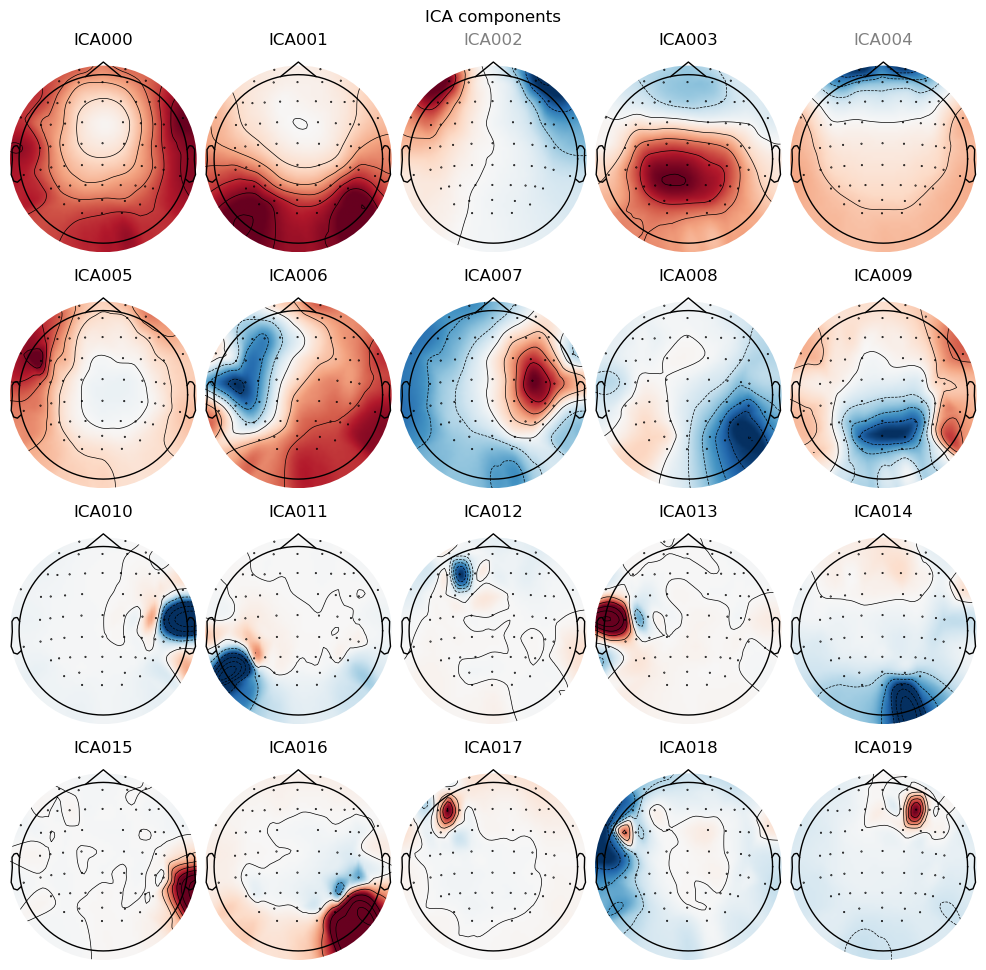

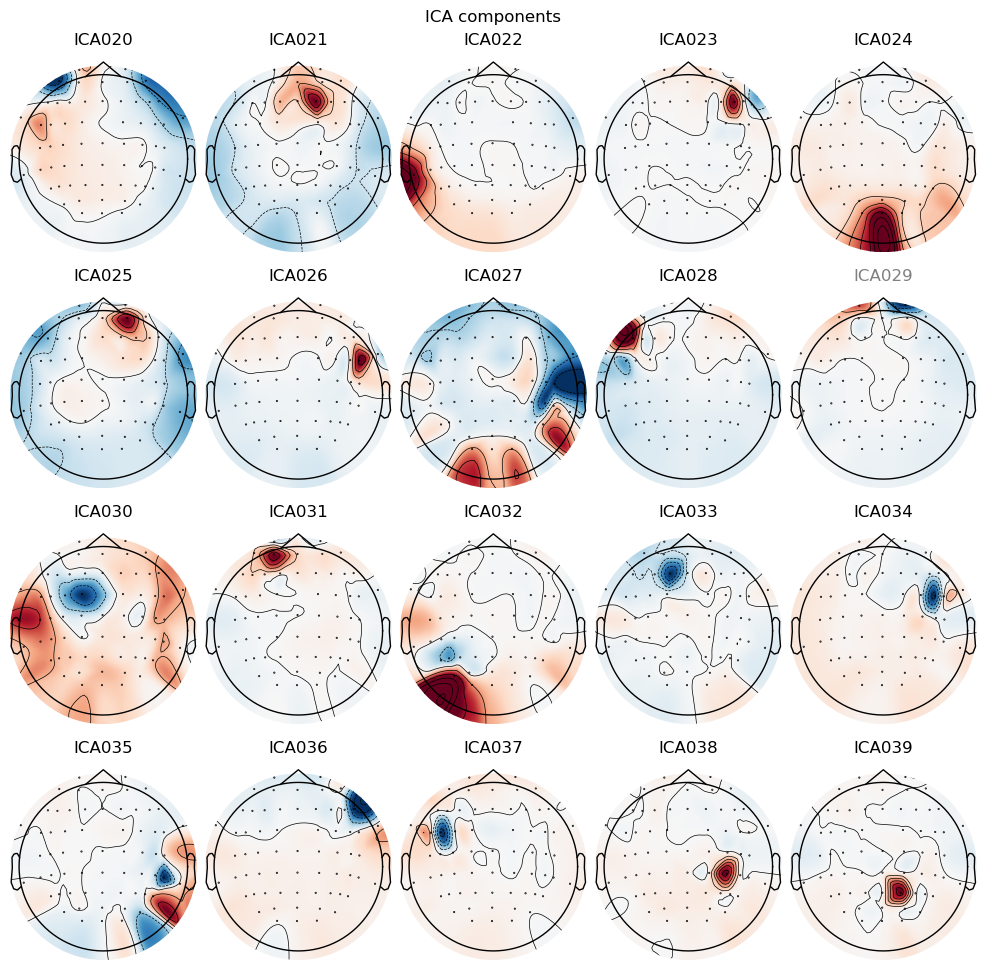

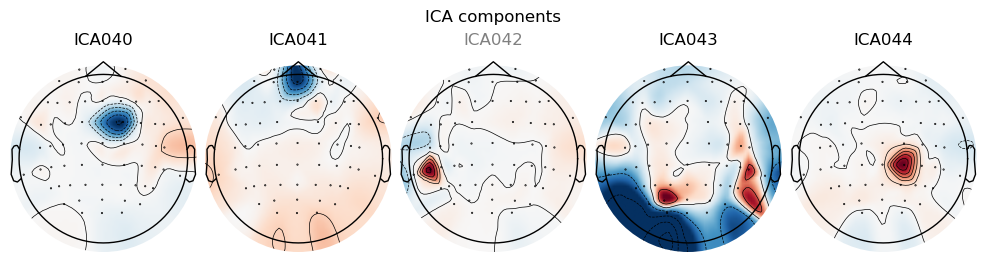

Creating RawArray with float64 data, n_channels=47, n_times=555780
    Range : 0 ... 555779 =      0.000 ...  2223.116 secs
Ready.
Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x24a2ad64180) at 0x0000024A2DCD4280>

In [20]:
# Alternativ/Zusätzlich: Visuelle Inspektion im Jupyter Notebook!
# Führe dies in einer eigenen Zelle aus:
ica.plot_components()
ica.plot_sources(raw_eeg)

In [21]:
# Wir nehmen für das Gerüst an, dass Komponenten 0 und 1 Blinzeln sind:
ica.exclude = [2, 4]  # Diese Liste nach deiner visuellen Inspektion anpassen!

print("Wende ICA auf die kontinuierlichen Raw-Daten an...")
raw_clean = raw_eeg.copy()
ica.apply(raw_clean)

Wende ICA auf die kontinuierlichen Raw-Daten an...
Applying ICA to Raw instance
    Transforming to ICA space (45 components)
    Zeroing out 2 ICA components
    Projecting back using 63 PCA components


<Raw | sub-14_task-loc_desc-filtResamp250_eeg.fif, 65 x 555780 (2223.1 s), ~275.7 MiB, data loaded>

In [22]:
# ==========================================
# SCHRITT 8: Final epoching
# ==========================================
print("Erstelle finale Epochen...")
# Hier setzt du deine tatsächlichen Trigger, tmin und tmax ein
tmin = -0.2  # 200ms vor Stimulus
tmax = 0.8   # 800ms nach Stimulus

# WICHTIG: baseline=None setzen, da wir das ganz am Schluss machen wollen!
epochs = mne.Epochs(raw_clean, events, event_id, tmin, tmax, 
                    baseline=None, preload=True, reject=None)

Erstelle finale Epochen...
Not setting metadata
1182 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1182 events and 251 original time points ...
0 bad epochs dropped


In [23]:
# ==========================================
# SCHRITT 9: Autoreject
# ==========================================
print("Führe Autoreject durch...")
# Autoreject lernt die Schwellenwerte datengetrieben und repariert Kanäle
ar = AutoReject(n_interpolate=[1, 2, 4], random_state=42, n_jobs=-1, verbose=True)

# fit_transform führt das Fitting durch und gibt direkt die bereinigten Epochen zurück
epochs_clean = ar.fit_transform(epochs)

Führe Autoreject durch...
Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/63 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/63 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/1182 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

  0%|          | Repairing epochs : 0/1182 [00:00<?,       ?it/s]

  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.90 and n_interpolate=4


  0%|          | Repairing epochs : 0/1182 [00:00<?,       ?it/s]

No bad epochs were found for your data. Returning a copy of the data you wanted to clean. Interpolation may have been done.


In [24]:
# ==========================================
# SCHRITT 10: Baseline correction
# ==========================================
print("Wende Baseline-Korrektur an...")
# Die Baseline ist in der Regel die Zeit vor dem Stimulus (tmin bis 0)
baseline_window = (tmin, 0)
epochs_clean.apply_baseline(baseline_window)

Wende Baseline-Korrektur an...
Applying baseline correction (mode: mean)


<Epochs | 1182 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~147.2 MiB, data loaded,
 np.str_('dist_end'): 1
 np.str_('dist_start'): 1
 np.str_('enc_act1'): 64
 np.str_('enc_act2'): 64
 np.str_('enc_act3'): 64
 np.str_('enc_cue'): 64
 np.str_('enc_end'): 1
 np.str_('enc_fixation'): 64
 np.str_('enc_q_color'): 32
 np.str_('enc_q_schema'): 32
 and 41 more events ...>

In [26]:
# ==========================================
# DATEN SPEICHERN
# ==========================================
print(f"Speichere finale, bereinigte Epochen unter: {fname_cleaned}")
epochs_clean.save(fname_cleaned, overwrite=True)
print("Fertig!")

print(fname_cleaned)

Speichere finale, bereinigte Epochen unter: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-cleanEpochs_eeg.fif


C:\Users\noahm\AppData\Local\Temp\ipykernel_22728\1974083652.py:5: RuntimeWarning: This filename (C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-cleanEpochs_eeg.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_clean.save(fname_cleaned, overwrite=True)


Fertig!
C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-14\eeg\sub-14_task-loc_desc-cleanEpochs_eeg.fif
